In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2


In [15]:
df = pd.read_csv('ecommerce_user_behavior.csv')
df.head(6)

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0
5,6.0,56.0,Female,Desktop,26.60,1.0,12.0,7.0,1.0,1.0,0.0,28.40,13.90,1.0


In [16]:
df = df.drop(columns=['user_id'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 7840 non-null   float64
 1   gender              7840 non-null   str    
 2   device_type         7840 non-null   str    
 3   time_on_site        7840 non-null   float64
 4   pages_viewed        7840 non-null   float64
 5   previous_purchases  7840 non-null   float64
 6   cart_items          7840 non-null   float64
 7   discount_seen       7840 non-null   float64
 8   ad_clicked          7840 non-null   float64
 9   returning_user      7840 non-null   float64
 10  avg_session_time    7840 non-null   float64
 11  bounce_rate         7840 non-null   float64
 12  purchase            7840 non-null   float64
dtypes: float64(11), str(2)
memory usage: 812.6 KB


In [17]:
df.describe()

,age,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
count,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000
mean,38.595791,15.714673,9.970026,6.964158,4.530230,0.502551,0.502296,0.509439,15.794999,49.924402,0.998342
std,12.033928,8.362764,5.425485,4.281117,2.865814,0.500025,0.500027,0.499943,9.864556,29.137449,0.040689
min,18.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.570000,0.010000,0.000000
25%,28.000000,8.520000,5.000000,3.000000,2.000000,0.000000,0.000000,0.000000,7.750000,24.677500,1.000000
50%,39.000000,15.740000,10.000000,7.000000,5.000000,1.000000,1.000000,1.000000,14.300000,49.500000,1.000000
75%,49.000000,22.880000,15.000000,11.000000,7.000000,1.000000,1.000000,1.000000,22.392500,75.990000,1.000000
max,59.000000,30.000000,19.000000,14.000000,9.000000,1.000000,1.000000,1.000000,44.750000,99.970000,1.000000


In [18]:
df.isnull().sum()

age                   160
gender                160
device_type           160
time_on_site          160
pages_viewed          160
previous_purchases    160
cart_items            160
discount_seen         160
ad_clicked            160
returning_user        160
avg_session_time      160
bounce_rate           160
purchase              160
dtype: int64

In [19]:
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 6138 entries, 1 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 6138 non-null   float64
 1   gender              6138 non-null   str    
 2   device_type         6138 non-null   str    
 3   time_on_site        6138 non-null   float64
 4   pages_viewed        6138 non-null   float64
 5   previous_purchases  6138 non-null   float64
 6   cart_items          6138 non-null   float64
 7   discount_seen       6138 non-null   float64
 8   ad_clicked          6138 non-null   float64
 9   returning_user      6138 non-null   float64
 10  avg_session_time    6138 non-null   float64
 11  bounce_rate         6138 non-null   float64
 12  purchase            6138 non-null   float64
dtypes: float64(11), str(2)
memory usage: 671.3 KB


In [20]:
df = df.drop_duplicates() # Elimina linhas duplicadas
df.info()

<class 'pandas.DataFrame'>
Index: 6138 entries, 1 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 6138 non-null   float64
 1   gender              6138 non-null   str    
 2   device_type         6138 non-null   str    
 3   time_on_site        6138 non-null   float64
 4   pages_viewed        6138 non-null   float64
 5   previous_purchases  6138 non-null   float64
 6   cart_items          6138 non-null   float64
 7   discount_seen       6138 non-null   float64
 8   ad_clicked          6138 non-null   float64
 9   returning_user      6138 non-null   float64
 10  avg_session_time    6138 non-null   float64
 11  bounce_rate         6138 non-null   float64
 12  purchase            6138 non-null   float64
dtypes: float64(11), str(2)
memory usage: 671.3 KB


In [21]:
df.isnull().sum()

age                   0
gender                0
device_type           0
time_on_site          0
pages_viewed          0
previous_purchases    0
cart_items            0
discount_seen         0
ad_clicked            0
returning_user        0
avg_session_time      0
bounce_rate           0
purchase              0
dtype: int64

In [22]:
# Features numéricas contínuas que precisam de padronização
df.columns = df.columns.str.strip()
numeric_features = ['time_on_site', 'age', 'pages_viewed', 'previous_purchases', 'cart_items', 'avg_session_time', 'bounce_rate']

scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

df[numeric_features].describe().round(2)

,time_on_site,age,pages_viewed,previous_purchases,cart_items,avg_session_time,bounce_rate
count,6138.00,6138.00,6138.00,6138.00,6138.00,6138.00,6138.00
mean,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.78,-1.71,-1.66,-1.63,-1.59,-1.55,-1.71
25%,-0.85,-0.88,-0.92,-0.93,-0.89,-0.81,-0.87
50%,0.01,0.03,0.00,0.00,0.16,-0.16,-0.02
75%,0.85,0.86,0.92,0.93,0.86,0.67,0.90
max,1.72,1.69,1.66,1.63,1.55,2.94,1.72


In [23]:
# One-Hot Encoding para variáveis categóricas
df = pd.get_dummies(df, columns=['device_type', 'gender'], drop_first=True)

print(f'Shape após encoding: {df.shape}')
print(f'Colunas: {list(df.columns)}')
df.head()

Shape após encoding: (6138, 14)
Colunas: ['age', 'time_on_site', 'pages_viewed', 'previous_purchases', 'cart_items', 'discount_seen', 'ad_clicked', 'returning_user', 'avg_session_time', 'bounce_rate', 'purchase', 'device_type_Mobile', 'device_type_Tablet', 'gender_Male']


,age,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase,device_type_Mobile,device_type_Tablet,gender_Male
1,0.613517,-0.014380,-0.183017,-0.695424,0.505683,1.0,1.0,1.0,0.340936,1.266843,1.0,True,False,True
4,-0.051578,1.277357,-0.183017,1.167132,-0.193784,1.0,0.0,0.0,0.237159,0.188559,1.0,True,False,False
5,1.444885,1.307482,-1.657486,1.167132,0.855417,1.0,1.0,0.0,1.280019,-1.235752,1.0,False,False,False
6,-0.217852,-0.981977,0.185600,0.934312,0.505683,1.0,1.0,1.0,-1.150609,-1.262555,1.0,True,False,True
7,0.114696,1.353271,-0.551635,-0.462605,-0.893250,1.0,0.0,0.0,1.782627,-1.280080,1.0,True,False,False


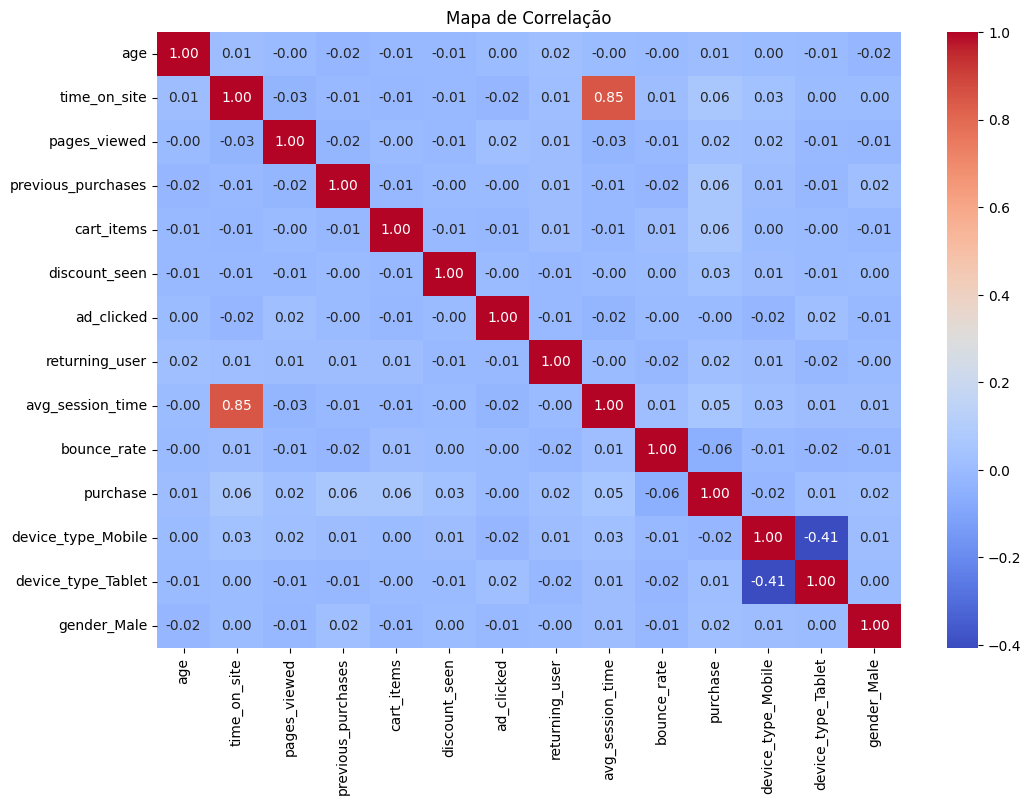

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# pega apenas colunas numéricas
corr = df.corr(numeric_only=True)

# cria o mapa de calor
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Mapa de Correlação")
plt.show()

In [25]:
# Separar features e target
cols_to_drop = [
    'age',
    'discount_seen',
    'ad_clicked',
    'returning_user',
    'avg_session_time',
    'bounce_rate',
    'device_type_Mobile',
    'device_type_Tablet',
    'gender_Male'
    
]

X = df.drop(columns=cols_to_drop + ['purchase'])
y = df['purchase']

# Dividir em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Criar DataFrames para treino e teste
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

# Salvar em arquivos CSV
train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)

print(f'Treino: {train_df.shape[0]} amostras')
print(f'Teste: {test_df.shape[0]} amostras')
print(f'Arquivos salvos: train.csv e test.csv')

Treino: 4910 amostras
Teste: 1228 amostras
Arquivos salvos: train.csv e test.csv


In [26]:
# Random Forest 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

# Carregar dados de treino e teste
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Separar features e target
X_train = train_df.drop('purchase', axis=1)
y_train = train_df['purchase']
X_test = test_df.drop('purchase', axis=1)
y_test = test_df['purchase']

print(f"Treino: {X_train.shape[0]} amostras - {y_train.value_counts().to_dict()}")
print(f"Teste: {X_test.shape[0]} amostras - {y_test.value_counts().to_dict()}")

# Criar e treinar o modelo Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=8, min_samples_leaf=5, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Previsões
y_pred = rf_model.predict(X_test)

# Avaliação do modelo
print("\n=== Random Forest ===")
print(f"Acurácia: {balanced_accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

Treino: 4910 amostras - {1.0: 4901, 0.0: 9}
Teste: 1228 amostras - {1.0: 1226, 0.0: 2}

=== Random Forest ===
Acurácia: 0.7484

Classification Report:
              precision    recall  f1-score   support

         0.0       0.20      0.50      0.29         2
         1.0       1.00      1.00      1.00      1226

    accuracy                           1.00      1228
   macro avg       0.60      0.75      0.64      1228
weighted avg       1.00      1.00      1.00      1228

Matriz de Confusão:
[[   1    1]
 [   4 1222]]
